In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Bhagyashree\Downloads\archive (1).zip")

df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [4]:
df.shape

(1048567, 9)

In [5]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='str')

In [6]:
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  str    
 1   CustomerID               1048567 non-null  str    
 2   CustomerDOB              1045170 non-null  str    
 3   CustGender               1047467 non-null  str    
 4   CustLocation             1048416 non-null  str    
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  str    
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 72.0 MB


In [12]:
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], format='%d/%m/%y', errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],format='%d/%m/%y', errors='coerce')

In [13]:
df[['CustomerDOB', 'TransactionDate']].dtypes

CustomerDOB        datetime64[us]
TransactionDate    datetime64[us]
dtype: object

In [14]:
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [15]:
df['CustGender'].value_counts(dropna=False)

CustGender
M      765530
F      281936
NaN      1100
T           1
Name: count, dtype: int64

In [16]:
df['CustGender'].value_counts(dropna=False)

CustGender
M      765530
F      281936
NaN      1100
T           1
Name: count, dtype: int64

In [17]:
df[df['CustGender'] == 'T']

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
959987,T959988,C3380368,1800-01-01,T,CHENNAI,50050.0,2016-10-09,170731,32500.0


In [18]:
df['CustGender'] = df['CustGender'].replace('T', pd.NA)

In [19]:
df['CustGender'].value_counts(dropna=False)

CustGender
M      765530
F      281936
NaN      1101
Name: count, dtype: int64

In [20]:
df['CustLocation'].isnull().sum()

np.int64(151)

In [21]:
df['CustLocation'].nunique()

9355

In [22]:
df['CustLocation'] = df['CustLocation'].fillna('Unknown')

In [23]:
df['CustLocation'].isnull().sum()

np.int64(0)

In [24]:
df['CustAccountBalance'].describe()

count    1.046198e+06
mean     1.154035e+05
std      8.464854e+05
min      0.000000e+00
25%      4.721760e+03
50%      1.679218e+04
75%      5.765736e+04
max      1.150355e+08
Name: CustAccountBalance, dtype: float64

In [25]:
df['CustAccountBalance'].isnull().sum()

np.int64(2369)

In [26]:
df['CustomerDOB'].isnull().sum()

np.int64(3397)

In [27]:
df['CustomerDOB'].describe()

count                       1045170
mean     1986-07-14 03:33:30.829243
min             1800-01-01 00:00:00
25%             1984-03-23 00:00:00
50%             1989-02-12 00:00:00
75%             1992-10-28 00:00:00
max             2075-12-31 00:00:00
Name: CustomerDOB, dtype: object

In [28]:
df[(df['CustomerDOB'].dt.year < 1900) | (df['CustomerDOB'].dt.year > 2020)].shape[0]

174907

In [29]:
df.loc[
    (df['CustomerDOB'].dt.year < 1900) |
    (df['CustomerDOB'].dt.year > 2020),
    'CustomerDOB'
] = pd.NaT

In [30]:
df['CustomerDOB'].isnull().sum()

np.int64(178304)

In [31]:
df['TransactionAmount (INR)'].describe()

count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64

In [32]:
(df['TransactionAmount (INR)'] < 0).sum()

np.int64(0)

In [33]:
df['TransactionDate'].describe()

count                       1048567
mean     2016-07-25 19:17:20.973823
min             2016-01-08 00:00:00
25%             2016-06-09 00:00:00
50%             2016-08-20 00:00:00
75%             2016-09-09 00:00:00
max             2016-12-09 00:00:00
Name: TransactionDate, dtype: object

In [34]:
((df['TransactionTime'] < 0) | (df['TransactionTime'] > 235959)).sum()

np.int64(0)

In [35]:
df['TransactionID'].duplicated().sum()

np.int64(0)

In [36]:
df['CustomerID'].nunique()

884265

In [37]:
df['Age'] = (
    df['TransactionDate'].dt.year - df['CustomerDOB'].dt.year
)

In [38]:
df['Age'].describe()

count    870263.000000
mean         28.533806
std           4.994574
min          -4.000000
25%          25.000000
50%          28.000000
75%          32.000000
max          40.000000
Name: Age, dtype: float64

In [39]:
from datetime import datetime

df['Age'] = (
    (df['TransactionDate'] - df['CustomerDOB']).dt.days / 365.25
).round(0)

In [40]:
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = pd.NA

In [41]:
df['Age'].describe()

count    868665.000000
mean         28.636304
std           4.974603
min          18.000000
25%          25.000000
50%          28.000000
75%          32.000000
max          41.000000
Name: Age, dtype: float64

In [42]:
df.to_csv("bank_transactions_cleaned.csv", index=False)

In [43]:
df['CustGender'].value_counts(dropna=False)

CustGender
M      765530
F      281936
NaN      1101
Name: count, dtype: int64

In [44]:
df['CustGender'].value_counts(normalize=True, dropna=False) * 100

CustGender
M      73.007257
F      26.887743
NaN     0.105000
Name: proportion, dtype: float64

In [45]:
df.groupby('CustGender')['TransactionAmount (INR)'].mean()

CustGender
F    1655.733753
M    1543.564378
Name: TransactionAmount (INR), dtype: float64

In [46]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 20, 25, 30, 35, 40, 45],
    labels=['18-20', '21-25', '26-30', '31-35', '36-40', '41-45']
)

In [47]:
df.groupby('AgeGroup', observed=True)['TransactionAmount (INR)'].mean()

AgeGroup
18-20     851.743145
21-25     857.066933
26-30    1182.504913
31-35    1590.138442
36-40    1960.198562
41-45    1854.137036
Name: TransactionAmount (INR), dtype: float64

In [48]:
df['CustLocation'].value_counts().head(10)

CustLocation
MUMBAI       103595
NEW DELHI     84928
BANGALORE     81555
GURGAON       73818
DELHI         71019
NOIDA         32784
CHENNAI       30009
PUNE          25851
HYDERABAD     23049
THANE         21505
Name: count, dtype: int64

In [49]:
df.groupby('CustLocation')['TransactionAmount (INR)'].sum().sort_values(ascending=False).head(10)

CustLocation
MUMBAI       1.796861e+08
NEW DELHI    1.607059e+08
BANGALORE    1.184248e+08
GURGAON      1.120947e+08
DELHI        1.062249e+08
KOLKATA      6.060031e+07
CHENNAI      4.463782e+07
NOIDA        4.446343e+07
PUNE         3.959035e+07
HYDERABAD    3.617739e+07
Name: TransactionAmount (INR), dtype: float64

In [50]:
df['Month'] = df['TransactionDate'].dt.to_period('M')

monthly_transactions = df['Month'].value_counts().sort_index()

monthly_transactions

Month
2016-01     42765
2016-02     43787
2016-03     47046
2016-04     47246
2016-05     42333
2016-06     46225
2016-07     48422
2016-08    430314
2016-09    158882
2016-10     51069
2016-11     47287
2016-12     43191
Freq: M, Name: count, dtype: int64

In [51]:
monthly_amount = df.groupby('Month')['TransactionAmount (INR)'].sum()

monthly_amount

Month
2016-01    6.310688e+07
2016-02    6.711734e+07
2016-03    7.646157e+07
2016-04    8.184117e+07
2016-05    6.806492e+07
2016-06    7.721579e+07
2016-07    7.616779e+07
2016-08    6.771927e+08
2016-09    2.450553e+08
2016-10    7.966956e+07
2016-11    7.352963e+07
2016-12    6.537303e+07
Freq: M, Name: TransactionAmount (INR), dtype: float64

In [52]:
monthly_avg = df.groupby('Month')['TransactionAmount (INR)'].mean()

monthly_avg

Month
2016-01    1475.666489
2016-02    1532.814395
2016-03    1625.251312
2016-04    1732.234817
2016-05    1607.845526
2016-06    1670.433483
2016-07    1572.999682
2016-08    1573.717579
2016-09    1542.373257
2016-10    1560.037630
2016-11    1554.964934
2016-12    1513.579800
Freq: M, Name: TransactionAmount (INR), dtype: float64

In [53]:
df['CustAccountBalance'].describe()

count    1.046198e+06
mean     1.154035e+05
std      8.464854e+05
min      0.000000e+00
25%      4.721760e+03
50%      1.679218e+04
75%      5.765736e+04
max      1.150355e+08
Name: CustAccountBalance, dtype: float64

In [54]:
df['BalanceCategory'] = pd.cut(
    df['CustAccountBalance'],
    bins=[-1, 5000, 20000, 50000, 100000, float('inf')],
    labels=['Below 5K', '5K-20K', '20K-50K', '50K-1L', 'Above 1L']
)

df['BalanceCategory'].value_counts()

BalanceCategory
5K-20K      293719
Below 5K    270036
20K-50K     195849
Above 1L    179004
50K-1L      107590
Name: count, dtype: int64

In [55]:
df['TransactionCategory'] = pd.cut(
    df['TransactionAmount (INR)'],
    bins=[-1, 500, 2000, 5000, 10000, float('inf')],
    labels=['Below 500', '500-2K', '2K-5K', '5K-10K', 'Above 10K']
)

df['TransactionCategory'].value_counts()

TransactionCategory
Below 500    571386
500-2K       319803
2K-5K        102591
5K-10K        30971
Above 10K     23816
Name: count, dtype: int64

In [56]:
customer_transaction_count = df.groupby('CustomerID').size()

customer_transaction_count.describe()

count    884265.000000
mean          1.185806
std           0.450683
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           6.000000
dtype: float64

In [57]:
customer_transaction_count.value_counts().sort_index()

1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64

In [58]:
customer_transaction_count.value_counts(normalize=True).sort_index() * 100

1    83.759167
2    14.131510
3     1.898639
4     0.192476
5     0.016624
6     0.001583
Name: proportion, dtype: float64

In [59]:
customer_total_amount = df.groupby('CustomerID')['TransactionAmount (INR)'].sum()

customer_total_amount.describe()

count    8.842650e+05
mean     1.866856e+03
std      7.207210e+03
min      0.000000e+00
25%      2.000000e+02
50%      5.368000e+02
75%      1.500000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64

In [60]:
customer_avg_amount = df.groupby('CustomerID')['TransactionAmount (INR)'].mean()

customer_avg_amount.describe()

count    8.842650e+05
mean     1.574781e+03
std      6.443050e+03
min      0.000000e+00
25%      1.920000e+02
50%      5.000000e+02
75%      1.248000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64

In [61]:
customer_transaction_count = customer_transaction_count.rename('TransactionCount')

customer_transaction_count.head()

CustomerID
C1010011    2
C1010012    1
C1010014    2
C1010018    1
C1010024    1
Name: TransactionCount, dtype: int64

In [63]:
customer_total_amount = customer_total_amount.rename('TotalAmount')
customer_avg_amount = customer_avg_amount.rename('AverageAmount')

In [64]:
customer_data = df.groupby('CustomerID').agg(
    AccountBalance=('CustAccountBalance', 'mean'),
    Age=('Age', 'mean'),
    Gender=('CustGender', 'first'),
    Location=('CustLocation', 'first')
)

customer_data = customer_data.join(customer_transaction_count)
customer_data = customer_data.join(customer_total_amount)
customer_data = customer_data.join(customer_avg_amount)

customer_data.head()

,AccountBalance,Age,Gender,Location,TransactionCount,TotalAmount,AverageAmount
CustomerID,,,,,,,
C1010011,76340.635,28.5,F,NOIDA,2,5106.0,2553.0
C1010012,24204.490,22.0,M,MUMBAI,1,1499.0,1499.0
C1010014,100112.950,28.0,F,MUMBAI,2,1455.0,727.5
C1010018,496.180,26.0,F,CHAMPARAN,1,30.0,30.0
C1010024,87058.650,NaN,M,KOLKATA,1,5000.0,5000.0


In [65]:
customer_data.shape

(884265, 7)

In [66]:
customer_data.isnull().sum()

AccountBalance        1665
Age                 131127
Gender                 804
Location                 0
TransactionCount         0
TotalAmount              0
AverageAmount            0
dtype: int64

In [67]:
customer_data.describe()

,AccountBalance,Age,TransactionCount,TotalAmount,AverageAmount
count,8.826000e+05,753138.000000,884265.000000,8.842650e+05,8.842650e+05
mean,1.151579e+05,28.635092,1.185806,1.866856e+03,1.574781e+03
std,8.012311e+05,4.793296,0.450683,7.207210e+03,6.443050e+03
min,0.000000e+00,18.000000,1.000000,0.000000e+00,0.000000e+00
25%,5.590570e+03,25.000000,1.000000,2.000000e+02,1.920000e+02
50%,1.871484e+04,28.000000,1.000000,5.368000e+02,5.000000e+02
75%,6.177764e+04,32.000000,1.000000,1.500000e+03,1.248000e+03
max,1.150355e+08,41.000000,6.000000,1.560035e+06,1.560035e+06


In [68]:
customer_data['TransactionCount'].value_counts().sort_index()

TransactionCount
1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64

In [69]:
customer_data['CustomerSegment'] = pd.cut(
    customer_data['TransactionCount'],
    bins=[0, 1, 2, float('inf')],
    labels=['One-Time Customer', 'Occasional Customer', 'Frequent Customer']
)

customer_data['CustomerSegment'].value_counts()

CustomerSegment
One-Time Customer      740653
Occasional Customer    124960
Frequent Customer       18652
Name: count, dtype: int64

In [70]:
customer_data.groupby('CustomerSegment', observed=True)['TotalAmount'].mean()

CustomerSegment
One-Time Customer      1575.450840
Occasional Customer    3142.186370
Frequent Customer      4894.152469
Name: TotalAmount, dtype: float64

In [71]:
customer_data.groupby('CustomerSegment', observed=True)['AccountBalance'].mean()

CustomerSegment
One-Time Customer      114772.686157
Occasional Customer    117627.971811
Frequent Customer      113871.266256
Name: AccountBalance, dtype: float64

In [72]:
customer_data.head()

,AccountBalance,Age,Gender,Location,TransactionCount,TotalAmount,AverageAmount,CustomerSegment
CustomerID,,,,,,,,
C1010011,76340.635,28.5,F,NOIDA,2,5106.0,2553.0,Occasional Customer
C1010012,24204.490,22.0,M,MUMBAI,1,1499.0,1499.0,One-Time Customer
C1010014,100112.950,28.0,F,MUMBAI,2,1455.0,727.5,Occasional Customer
C1010018,496.180,26.0,F,CHAMPARAN,1,30.0,30.0,One-Time Customer
C1010024,87058.650,NaN,M,KOLKATA,1,5000.0,5000.0,One-Time Customer


In [73]:
import matplotlib.pyplot as plt

customer_data['CustomerSegment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [77]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [78]:
import matplotlib.pyplot as plt

customer_data['CustomerSegment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import matplotlib.pyplot as plt

customer_data['CustomerSegment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

NameError: name 'customer_data' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("bank_transactions_cleaned.csv")
df.shape

(1048567, 10)

In [4]:
customer_data = df.groupby('CustomerID').agg(
    AccountBalance=('CustAccountBalance', 'mean'),
    Age=('Age', 'mean'),
    Gender=('CustGender', 'first'),
    Location=('CustLocation', 'first'),
    TransactionCount=('TransactionID', 'count'),
    TotalAmount=('TransactionAmount (INR)', 'sum'),
    AverageAmount=('TransactionAmount (INR)', 'mean')
)

customer_data.head()

,AccountBalance,Age,Gender,Location,TransactionCount,TotalAmount,AverageAmount
CustomerID,,,,,,,
C1010011,76340.635,28.5,F,NOIDA,2,5106.0,2553.0
C1010012,24204.490,22.0,M,MUMBAI,1,1499.0,1499.0
C1010014,100112.950,28.0,F,MUMBAI,2,1455.0,727.5
C1010018,496.180,26.0,F,CHAMPARAN,1,30.0,30.0
C1010024,87058.650,NaN,M,KOLKATA,1,5000.0,5000.0


In [5]:
customer_data['CustomerSegment'] = pd.cut(
    customer_data['TransactionCount'],
    bins=[0, 1, 2, float('inf')],
    labels=['One-Time Customer', 'Occasional Customer', 'Frequent Customer']
)

customer_data['CustomerSegment'].value_counts()

CustomerSegment
One-Time Customer      740653
Occasional Customer    124960
Frequent Customer       18652
Name: count, dtype: int64

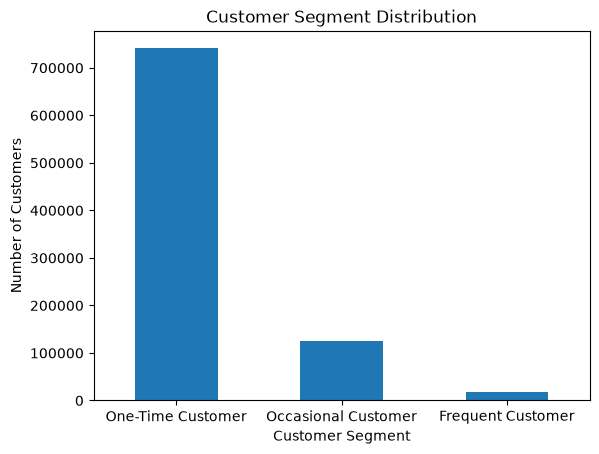

In [6]:
import matplotlib.pyplot as plt

customer_data['CustomerSegment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

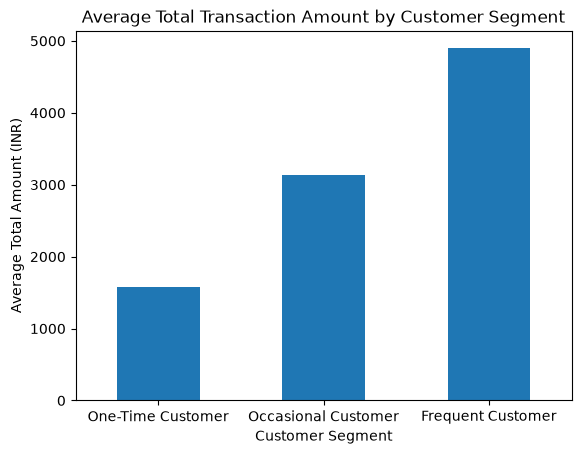

In [7]:
customer_data.groupby('CustomerSegment', observed=True)['TotalAmount'].mean().plot(kind='bar')

plt.title('Average Total Transaction Amount by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Total Amount (INR)')
plt.xticks(rotation=0)
plt.show()

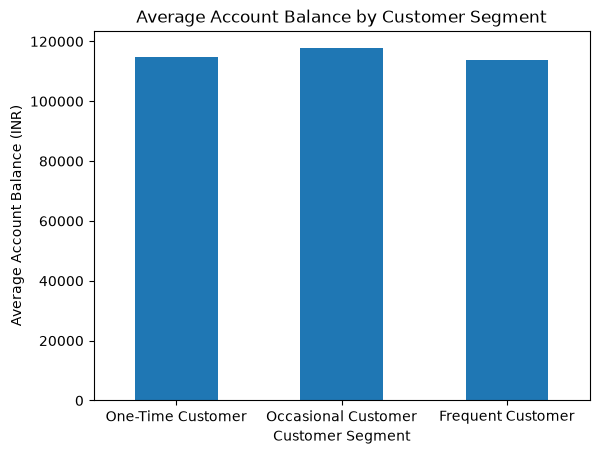

In [8]:
customer_data.groupby('CustomerSegment', observed=True)['AccountBalance'].mean().plot(kind='bar')

plt.title('Average Account Balance by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Account Balance (INR)')
plt.xticks(rotation=0)
plt.show()

In [9]:
segment_percentage = (
    customer_data['CustomerSegment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_percentage)

CustomerSegment
One-Time Customer      83.76
Occasional Customer    14.13
Frequent Customer       2.11
Name: proportion, dtype: float64


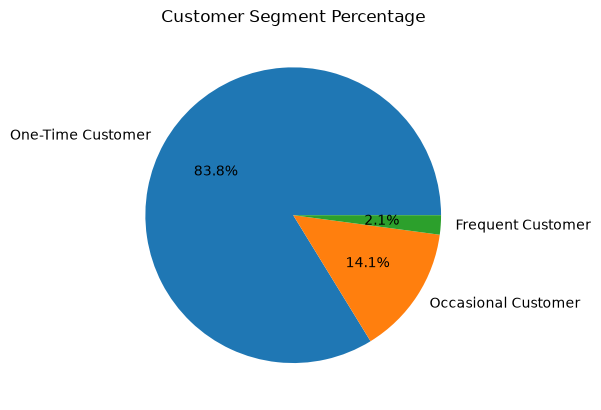

In [10]:
segment_percentage.plot(kind='pie', autopct='%1.1f%%')

plt.title('Customer Segment Percentage')
plt.ylabel('')
plt.show()

In [11]:
top_customers = customer_data.sort_values(
    by='TotalAmount',
    ascending=False
).head(10)

top_customers[['TotalAmount', 'TransactionCount', 'AverageAmount']]

,TotalAmount,TransactionCount,AverageAmount
CustomerID,,,
C7319271,1560034.99,1,1560034.99
C6677159,1380002.88,1,1380002.88
C4141768,991132.22,1,991132.22
C8217728,724472.00,2,362236.00
C1830891,720001.16,1,720001.16
C6549785,600008.32,1,600008.32
C5036642,600003.45,1,600003.45
C4328064,569500.27,1,569500.27
C1425138,561001.00,1,561001.00


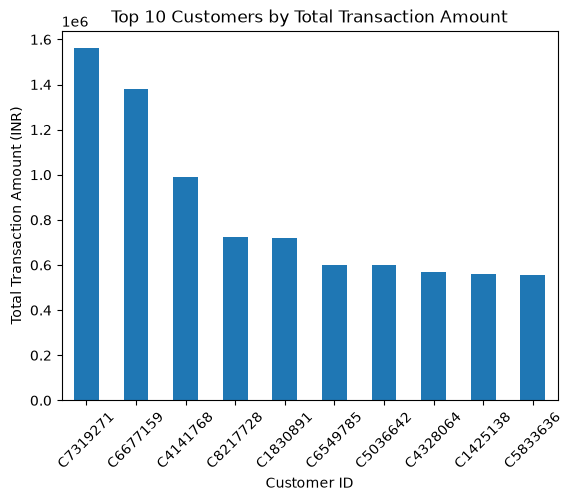

In [12]:
top_customers['TotalAmount'].plot(kind='bar')

plt.title('Top 10 Customers by Total Transaction Amount')
plt.xlabel('Customer ID')
plt.ylabel('Total Transaction Amount (INR)')
plt.xticks(rotation=45)
plt.show()

In [13]:
gender_amount = df.groupby('CustGender')['TransactionAmount (INR)'].mean()

print(gender_amount)

CustGender
F    1655.733753
M    1543.564378
Name: TransactionAmount (INR), dtype: float64


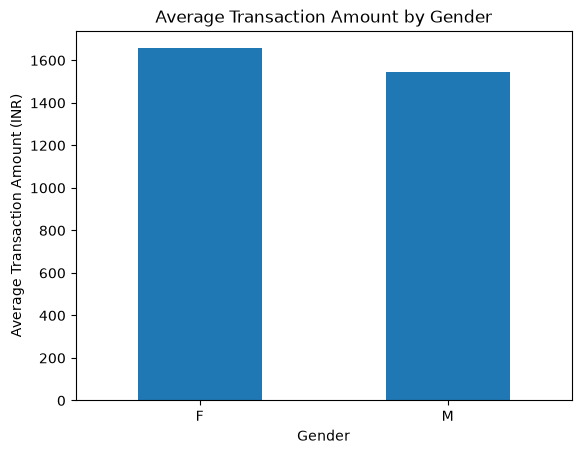

In [14]:
gender_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Transaction Amount (INR)')
plt.xticks(rotation=0)
plt.show()

In [1]:
age_group_amount = df.groupby('AgeGroup', observed=True)['TransactionAmount (INR)'].mean()

print(age_group_amount)

NameError: name 'df' is not defined

In [2]:
import os

print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', 'AppData', 'Application Data', 'bank_transactions_cleaned.csv', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'edsproject', 'Favorites', 'Hello.class', 'Hello.java', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{23e9c9b9-9c89-11f0-92ab-9cc7d3c4a17b}.TM.blf', 'NTUSER.DAT{23e9c9b9-9c89-11f0-92ab-9cc7d3c4a17b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{23e9c9b9-9c89-11f0-92ab-9cc7d3c4a17b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Videos', 'WPS Cloud']


In [3]:
import pandas as pd

df = pd.read_csv('bank_transactions_cleaned.csv')

print(df.shape)

(1048567, 10)


In [4]:
print(df['AgeGroup'].value_counts())

KeyError: 'AgeGroup'

In [5]:
print(df.columns.tolist())

['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)', 'Age']


In [6]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 20, 30, 40, 50, 60, 70, 100],
    labels=['18-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+'],
    include_lowest=True
)

print(df['AgeGroup'].value_counts().sort_index())

AgeGroup
18-20     21131
21-30    561459
31-40    283953
41-50      2122
51-60         0
61-70         0
71+           0
Name: count, dtype: int64


In [7]:
age_group_amount = df.groupby('AgeGroup', observed=True)['TransactionAmount (INR)'].mean()

print(age_group_amount)

AgeGroup
18-20     851.743145
21-30    1041.336823
31-40    1718.943286
41-50    1854.137036
Name: TransactionAmount (INR), dtype: float64


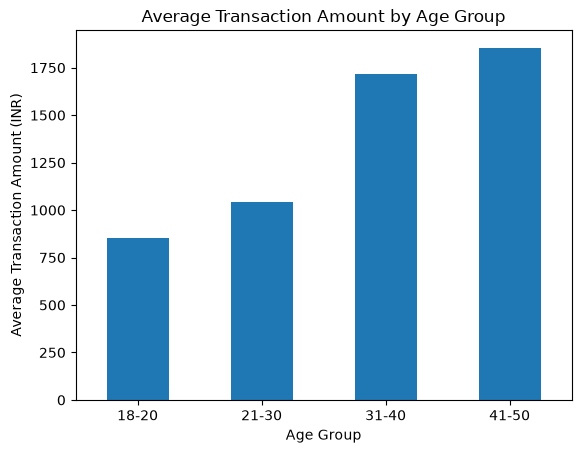

In [8]:
import matplotlib.pyplot as plt

age_group_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Amount (INR)')
plt.xticks(rotation=0)
plt.show()

In [9]:
gender_count = df['CustGender'].value_counts()

print(gender_count)

CustGender
M    765530
F    281936
Name: count, dtype: int64


In [10]:
gender_amount = df.groupby('CustGender')['TransactionAmount (INR)'].mean()

print(gender_amount)

CustGender
F    1655.733753
M    1543.564378
Name: TransactionAmount (INR), dtype: float64


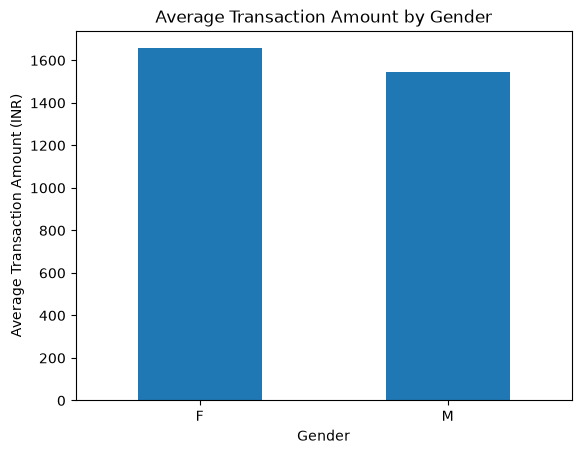

In [11]:
gender_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Transaction Amount (INR)')
plt.xticks(rotation=0)
plt.show()

In [12]:
location_count = df['CustLocation'].value_counts().head(10)

print(location_count)

CustLocation
MUMBAI       103595
NEW DELHI     84928
BANGALORE     81555
GURGAON       73818
DELHI         71019
NOIDA         32784
CHENNAI       30009
PUNE          25851
HYDERABAD     23049
THANE         21505
Name: count, dtype: int64


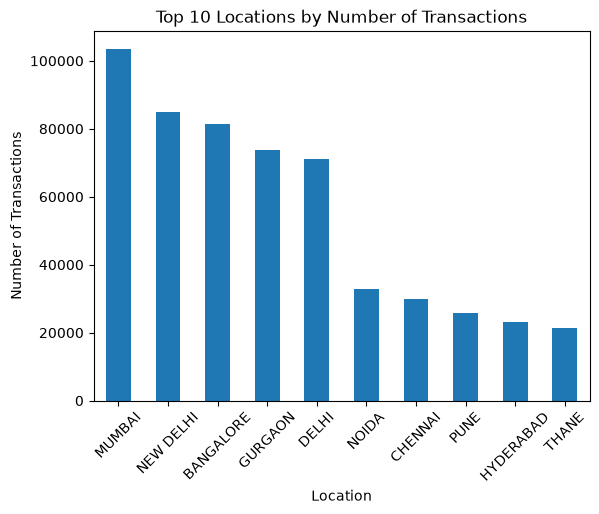

In [13]:
location_count.plot(kind='bar')

plt.title('Top 10 Locations by Number of Transactions')
plt.xlabel('Location')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

In [14]:
gender_balance = df.groupby('CustGender')['CustAccountBalance'].mean()

print(gender_balance)

CustGender
F    109799.607822
M    117592.033084
Name: CustAccountBalance, dtype: float64


In [15]:
age_group_balance = df.groupby('AgeGroup', observed=True)['CustAccountBalance'].mean()

print(age_group_balance)

AgeGroup
18-20     30540.973996
21-30     52412.305839
31-40    123646.538602
41-50    157064.596400
Name: CustAccountBalance, dtype: float64


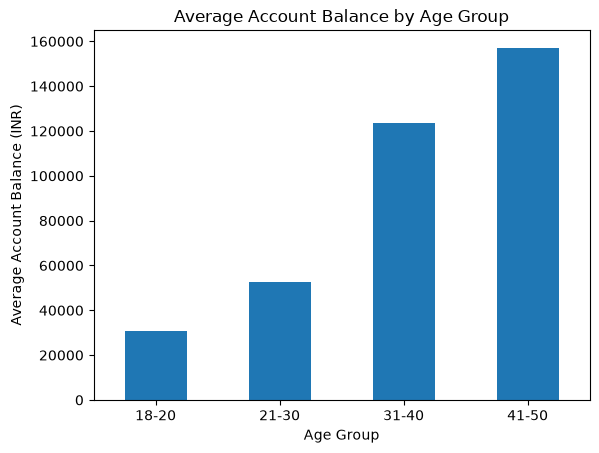

In [16]:
age_group_balance.plot(kind='bar')

plt.title('Average Account Balance by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Account Balance (INR)')
plt.xticks(rotation=0)
plt.show()

In [17]:
location_balance = df.groupby('CustLocation')['CustAccountBalance'].mean()

location_balance = location_balance.sort_values(ascending=False).head(10)

print(location_balance)

CustLocation
PO BOX 28483 DUBAI               2.169666e+07
RENTON                           2.077310e+07
SULTANATE OF OMAN                1.659912e+07
MERCEDES SHOWROOM MUMBAI         7.567497e+06
SHILLONG                         7.240424e+06
AHMADI                           7.090441e+06
SOMAJIGUDA HYDERABAD             6.503694e+06
BORIVALI WEST                    6.011186e+06
SAKAKA                           5.441525e+06
(W) NEAR RAMDEV MANDIR MUMBAI    5.208462e+06
Name: CustAccountBalance, dtype: float64


In [18]:
location_stats = df.groupby('CustLocation').agg(
    TransactionCount=('TransactionID', 'count'),
    AverageBalance=('CustAccountBalance', 'mean')
)

location_stats = location_stats[location_stats['TransactionCount'] >= 100]

location_balance = location_stats.sort_values(
    'AverageBalance',
    ascending=False
).head(10)

print(location_balance)

                 TransactionCount  AverageBalance
CustLocation                                     
SHILLONG                      168    7.240424e+06
ABU DHABI                     145    1.079451e+06
RIYADH                        100    8.378246e+05
TIRUPUR                       518    6.220238e+05
DOHA                          182    5.712367e+05
HOSPITAL MUMBAI               224    4.996040e+05
DUBAI                         492    4.331956e+05
PORVORIM                      172    3.644869e+05
SHARJAH                       161    3.523956e+05
MUSCAT                        119    3.391103e+05


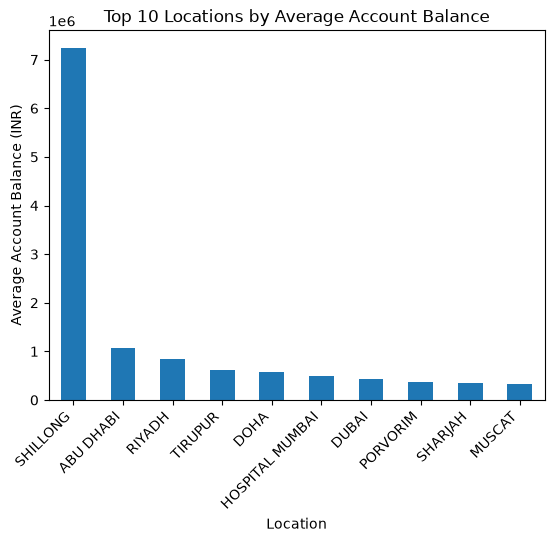

In [19]:
location_balance['AverageBalance'].plot(kind='bar')

plt.title('Top 10 Locations by Average Account Balance')
plt.xlabel('Location')
plt.ylabel('Average Account Balance (INR)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [20]:
transaction_amount = df['TransactionAmount (INR)']

print(transaction_amount.describe())

count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64


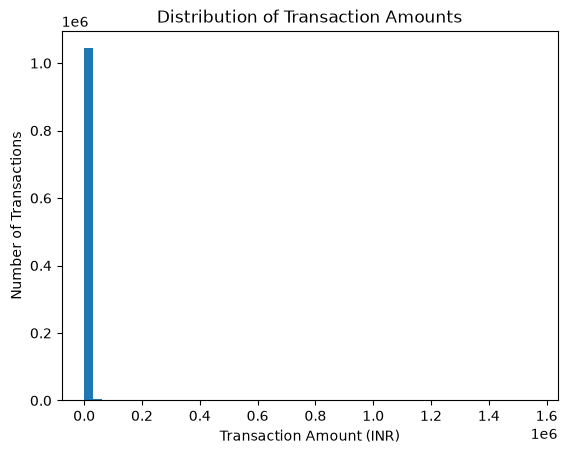

In [21]:
df['TransactionAmount (INR)'].plot(
    kind='hist',
    bins=50
)

plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount (INR)')
plt.ylabel('Number of Transactions')
plt.show()

In [22]:
top_transactions = df[
    ['TransactionID', 'CustomerID', 'CustLocation', 'TransactionAmount (INR)']
].sort_values(
    'TransactionAmount (INR)',
    ascending=False
).head(10)

print(top_transactions)

       TransactionID CustomerID       CustLocation  TransactionAmount (INR)
399117       T399118   C7319271            GURGAON               1560034.99
579014       T579015   C6677159               PUNE               1380002.88
532036       T532037   C4141768          NEW DELHI                991132.22
749353       T749354   C8217728             MUMBAI                724122.00
56540         T56541   C1830891            KOLKATA                720001.16
846924       T846925   C6549785              NOIDA                600008.32
173291       T173292   C5036642          NEW DELHI                600003.45
356306       T356307   C4328064              DELHI                569500.27
152735       T152736   C1425138             MUMBAI                561001.00
403383       T403384   C5833636  PALAKKARAI TRICHY                557000.73


In [23]:
segment_count = df.groupby('CustomerSegment')['CustomerID'].nunique()

print(segment_count)

KeyError: 'CustomerSegment'

In [24]:
transaction_count = df.groupby('CustomerID')['TransactionID'].count()

df['TransactionCount'] = df['CustomerID'].map(transaction_count)

df['CustomerSegment'] = pd.cut(
    df['TransactionCount'],
    bins=[0, 1, 5, float('inf')],
    labels=['One-Time Customer', 'Occasional Customer', 'Frequent Customer']
)

print(df['CustomerSegment'].value_counts())

CustomerSegment
One-Time Customer      740653
Occasional Customer    307830
Frequent Customer          84
Name: count, dtype: int64


In [25]:
segment_count = df.groupby('CustomerSegment', observed=True)['CustomerID'].nunique()

print(segment_count)

CustomerSegment
One-Time Customer      740653
Occasional Customer    143598
Frequent Customer          14
Name: CustomerID, dtype: int64


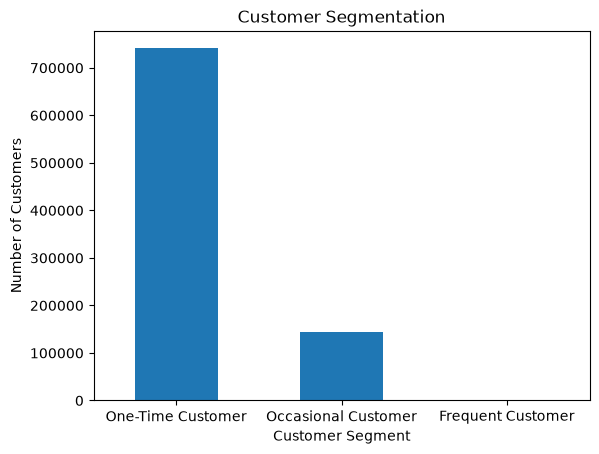

In [26]:
segment_count.plot(kind='bar')

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [27]:
segment_amount = df.groupby(
    'CustomerSegment',
    observed=True
)['TransactionAmount (INR)'].mean()

print(segment_amount)

CustomerSegment
One-Time Customer      1575.450840
Occasional Customer    1571.587607
Frequent Customer      1803.898571
Name: TransactionAmount (INR), dtype: float64


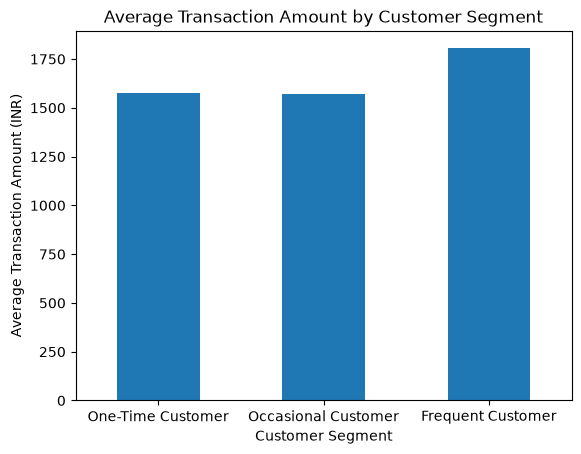

In [28]:
segment_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Transaction Amount (INR)')
plt.xticks(rotation=0)
plt.show()

In [29]:
segment_transactions = df['CustomerSegment'].value_counts()

print(segment_transactions)

CustomerSegment
One-Time Customer      740653
Occasional Customer    307830
Frequent Customer          84
Name: count, dtype: int64


In [30]:
df.to_csv('bank_transactions_final.csv', index=False)

print("Final dataset saved successfully!")
print(df.shape)

Final dataset saved successfully!
(1048567, 13)


In [31]:
import os
print(os.getcwd())

C:\Users\Bhagyashree


In [1]:
sample_df = df.sample(5000, random_state=42)

sample_df.to_csv('bank_transactions_sample.csv', index=False)

print("Sample file created successfully!")
print(sample_df.shape)

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv('bank_transactions_final.csv')

print(df.shape)

(1048567, 13)


In [3]:
sample_df = df.sample(5000, random_state=42)

sample_df.to_csv('bank_transactions_sample.csv', index=False)

print("Sample file created successfully!")
print(sample_df.shape)

Sample file created successfully!
(5000, 13)
